In [21]:
##Chill_EDA***

#Exploratory Data Analysis - RescueGroup Animal Adoption DataSet # type: ignore

#This notebook explores the dataset pulled from the RescueGroup API

#Data  Https://api.rescuegroups.org/v5/public/animals/search/cats/





#Data Loading and Inspection

In [22]:
import pandas as pd
import matplotlib.pyplot as plt


In [23]:
# Check the cleaned data
df = pd.read_csv('../data/clean/clean_cats_data.csv')
df.head()


,Unnamed: 0,id,sex,sizeCurrent,sizeGroup,ageGroup,ageString,breedString,colorDetails,vocalLevel,...,isKidsOk,adultSexesOk,obedienceTraining,ownerExperience,newPeopleReaction,pictureCount,videoCount,adoptedDate,availableDate,length_of_stay
0,2,10000193,Male,14.0,Large,Adult,8 Years 8 Months,Domestic Short Hair / Mixed,NaN,NaN,...,True,NaN,NaN,NaN,NaN,5,0,2016-08-13 00:00:00+00:00,2016-05-17 00:00:00+00:00,88.0
1,9,10000236,Female,NaN,NaN,Adult,10 Years 6 Months,Domestic Short Hair (short coat),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4,0,2016-06-25 00:00:00+00:00,2016-05-14 00:00:00+00:00,42.0
2,10,10000242,Female,NaN,NaN,Baby,6 Years 8 Months,Domestic Short Hair (short coat),White w/calico,NaN,...,NaN,NaN,NaN,NaN,NaN,2,0,2016-05-28 00:00:00+00:00,2016-05-14 00:00:00+00:00,14.0
3,11,10000252,Female,NaN,NaN,Baby,6 Years 8 Months,Domestic Short Hair (short coat),Tabby w/white,NaN,...,NaN,NaN,NaN,NaN,NaN,2,0,2016-05-28 00:00:00+00:00,2016-05-14 00:00:00+00:00,14.0
4,20,10000959,Male,NaN,Medium,Adult,NaN,Domestic Short Hair (short coat),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,0,2016-06-11 00:00:00+00:00,2016-05-13 00:00:00+00:00,29.0


In [24]:
print(f"Dataset Shape: {df.shape}")
#Check total rows and columns

Dataset Shape: (4528, 27)


In [25]:
print("\nMissing values in Length of Stay:", df['length_of_stay'].isna().sum())



Missing values in Length of Stay: 0


In [26]:
#The most common age group
most_common_age = df['ageGroup'].mode()[0]
print(f"The most common age group is: {most_common_age}")

The most common age group is: Baby


In [27]:
# The breakdown of cat ages
print("\nAge Group Breakdown:")
print(df['ageGroup'].value_counts)


Age Group Breakdown:
<bound method IndexOpsMixin.value_counts of 0       Adult
1       Adult
2        Baby
3        Baby
4       Adult
        ...  
4523    Young
4524    Young
4525     Baby
4526     Baby
4527    Young
Name: ageGroup, Length: 4528, dtype: str>


In [ ]:
# Group by the Age column and calculate the mean stay
#Who stays in the Shelter the longest? shortest?

age_stay_comparison = df.groupby('ageGroup')['length_of_stay'].mean().sort_values(ascending=False)

print("Average Length of Stay by Age Group (in days):")
print(age_stay_comparison)

Average Length of Stay by Age Group (in days):
ageGroup
Senior    389.018519
Adult     152.297262
Young      72.950281
Baby       43.055087
Name: length_of_stay, dtype: float64


C:\Users\Work\AppData\Local\Temp\ipykernel_32480\2952037919.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_stay_comparison.index, y=age_stay_comparison.values, palette='pastel')


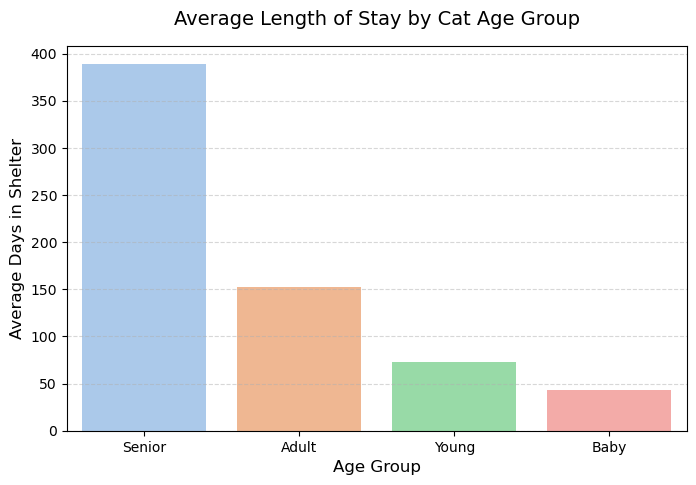

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting area
plt.figure(figsize=(8, 5))
sns.barplot(x=age_stay_comparison.index, y=age_stay_comparison.values, palette='pastel')

#Add hue

# Add labels and formatting
plt.title('Average Length of Stay by Cat Age Group', fontsize=14, pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Days in Shelter', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show the plot
plt.show()